# **Emotion Detection Emotion Dataset - Comparison**

### Install Dependencies

In [ ]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets
!pip install -q psutil

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import torch
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, AutoConfig
)
from peft import LoraConfig, TaskType, get_peft_model

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Load and Explore Data

Total instances: 75000
Number of instances per sentiment:
Sentiment
joy         25238
sadness     21830
anger       10218
fear         8698
love         6249
surprise     2767
Name: count, dtype: int64


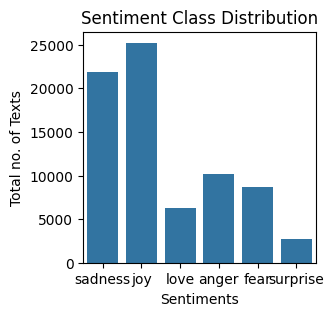

In [ ]:
file_path = "/content/drive/MyDrive/Emotion Dataset.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df = df[['Text', 'Sentiment']].dropna()
df.head()

# file_path = "/home/arafatmdeasin/usman/project/dataset/Emotion Dataset.csv"
# df = pd.read_csv(file_path, encoding='ISO-8859-1')
# df = df[['Text', 'Sentiment']].dropna()
# df.head()

total_instances = len(df)
print(f"Total instances: {total_instances}")

sentiment_counts = df['Sentiment'].value_counts()
print("Number of instances per sentiment:")
print(sentiment_counts)

plt.figure(figsize=(3,3))
sns.countplot(data=df, x='Sentiment')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Total no. of Texts")
plt.grid(False)
plt.show()

### Preprocessing

In [ ]:
label_mapping = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5
}

df['label'] = df['Sentiment'].map(label_mapping)

df = df.dropna(subset=['label'])

print("Label Mapping:")
for k, v in label_mapping.items():
    print(f"{k}: {v}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Train size: {len(train_texts)}, Val size: {len(val_texts)}, Test size: {len(test_texts)}")

Label Mapping:
sadness: 0
joy: 1
love: 2
anger: 3
fear: 4
surprise: 5
Train size: 60000, Val size: 7500, Test size: 7500


### Tokenization

In [ ]:
base_model_name = "distilbert-base-uncased"
finetuned_model_name = "bhadresh-savani/distilbert-base-uncased-emotion"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings   = tokenizer(val_texts, truncation=True, padding=True, max_length=512)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=512)


### Dataset Class

In [ ]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset  = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

### Utility Functions

In [ ]:
def get_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / 1024**3
    return 0

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")

    sims = []
    for i in range(len(labels)):
        true_onehot = np.zeros(proba.shape[1])
        true_onehot[labels[i]] = 1
        sims.append(cosine_similarity([true_onehot], [proba[i]])[0][0])
    similarity_score = np.mean(sims) * 100

    confidence_score = np.mean(np.max(proba, axis=1)) * 100

    return {
        "eval_Accuracy": acc,
        "eval_Precision": prec * 100,
        "eval_Recall": rec * 100,
        "eval_F1 Score": f1 * 100,
        "eval_Similarity Score": similarity_score,
        "eval_Confidence Score": confidence_score
    }


results = {}

### Baseline Models Evaluation

In [ ]:
print("=== BASELINE MODELS EVALUATION ===\n")

# Baseline DistilBERT
print("Evaluating Baseline DistilBERT...")
baseline_model = AutoModelForSequenceClassification.from_pretrained(finetuned_model_name)
baseline_trainer = Trainer(
    model=baseline_model,
    args=TrainingArguments(output_dir="./results", per_device_eval_batch_size=32, report_to="none"),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
baseline_metrics = baseline_trainer.evaluate()
results['baseline_distilbert'] = baseline_metrics

print("\n===== Performance of DistilBERT Model =====\n")
metrics_to_show = ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]
for metric in metrics_to_show:
    key = f"eval_{metric}"
    if key in baseline_metrics:
        print(f"{metric} is: {baseline_metrics[key]:.2f}%")

=== BASELINE MODELS EVALUATION ===

Evaluating Baseline DistilBERT...


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)



===== Performance of DistilBERT Model =====

Accuracy is: 93.15%
Precision is: 89.68%
Recall is: 90.10%
F1 Score is: 89.87%
Similarity Score is: 94.63%
Confidence Score is: 96.69%


### Baseline Confusion Matrices


=== BASELINE CONFUSION MATRIX ===


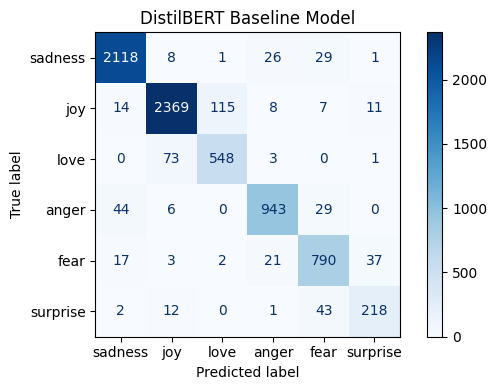

8329

In [ ]:
print("\n=== BASELINE CONFUSION MATRIX ===")
preds = baseline_trainer.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

class_names = list(label_mapping.keys())

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("DistilBERT Baseline Model")
plt.tight_layout()
plt.show()

del baseline_model, baseline_trainer
torch.cuda.empty_cache()
gc.collect()

### Fine-tuning BERT

In [ ]:
print("=== FINE-TUNING DistilBERT ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

config = AutoConfig.from_pretrained(
    base_model_name,
    num_labels=len(label_mapping),
    hidden_dropout_prob=0.4,
    attention_probs_dropout_prob=0.4
)

model_base = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    config=config
)

total_params_before = sum(p.numel() for p in model_base.parameters())
trainable_params_before = sum(p.numel() for p in model_base.parameters() if p.requires_grad)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    weight_decay=0.05,
    load_best_model_at_end=True,
    metric_for_best_model="eval_F1 Score",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    gradient_accumulation_steps=2,
    save_total_limit=2,
    max_grad_norm=1.0
)

trainer_base = Trainer(
    model=model_base,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer_base.train()
training_time = time.time() - start_time

gpu_memory = get_gpu_memory()

finetuned_metrics = trainer_base.evaluate(test_dataset)

results['finetuned_distilbert'] = {
    **finetuned_metrics,
    'training_time': training_time,
    'total_parameters': total_params_before,
    'trainable_parameters': trainable_params_before,
    'gpu_memory_gb': gpu_memory
}

=== FINE-TUNING DistilBERT ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated.

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.383200,0.150468,93.413333,89.816488,91.348644,90.238549,94.979649,95.682266
2,0.127300,0.125130,93.546667,89.471132,92.420895,90.731351,95.438715,95.599243
3,0.102900,0.118370,93.653333,89.202519,92.961774,90.825152,95.576627,95.489792


### Fine-tuned Confusion Matrices


=== FINE-TUNED CONFUSION MATRIX ===


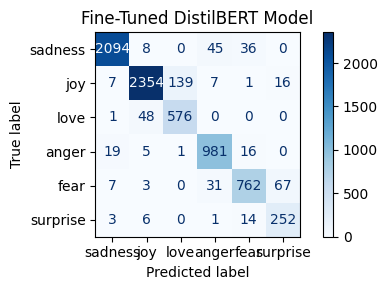

In [ ]:
print("\n=== FINE-TUNED CONFUSION MATRIX ===")
preds = trainer_base.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("Fine-Tuned DistilBERT Model")
plt.tight_layout()
plt.show()

### Fine-tuned Training & Validation Loss

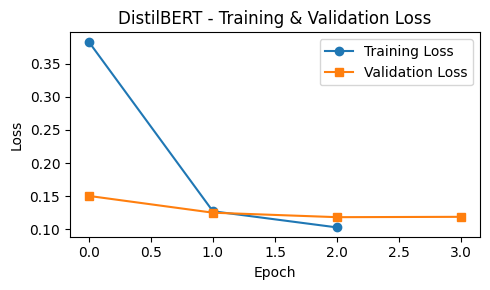

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_base.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_base.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('DistilBERT - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
import gc, torch

for var_name in ["model_base", "trainer_base"]:
    if var_name in globals():
        del globals()[var_name]

torch.cuda.empty_cache()
gc.collect()


15552

### Adapter (LoRA) BERT

In [ ]:
print("=== ADAPTER (LoRA) DistilBERT OPTIMIZED ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

adapter_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=len(label_mapping)
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    bias="none",
)

adapter_model = get_peft_model(adapter_model, peft_config)
adapter_model.print_trainable_parameters()

adapter_args = TrainingArguments(
    output_dir="./results-adapter",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=48,
    per_device_eval_batch_size=96,
    num_train_epochs=5,
    weight_decay=0.02,
    warmup_ratio=0.03,
    logging_dir="./logs-adapter",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=42,
    fp16=True,
    gradient_accumulation_steps=1,
    max_grad_norm=1.0,
    logging_steps=50,
    save_total_limit=2,
    lr_scheduler_type="cosine",
)

trainer_adapter = Trainer(
    model=adapter_model,
    args=adapter_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=1),
    ]
)

trainer_adapter.train()
training_time_lora = time.time() - start_time

gpu_memory_lora = get_gpu_memory()

adapter_metrics = trainer_adapter.evaluate(test_dataset)

results['adapter_distilbert'] = {
    **adapter_metrics,
    'training_time': training_time_lora,
    'total_parameters': sum(p.numel() for p in adapter_model.parameters()),
    'trainable_parameters': sum(p.numel() for p in adapter_model.parameters() if p.requires_grad),
    'gpu_memory_gb': gpu_memory_lora
}

=== ADAPTER (LoRA) DistilBERT OPTIMIZED ===


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 668,934 || all params: 67,627,020 || trainable%: 0.9892


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.486000,0.166054,92.893333,89.630399,90.216904,89.609012,94.546156,94.562775
2,0.180400,0.125384,93.373333,89.668520,91.821253,90.568794,95.405666,94.780746
3,0.138600,0.122927,93.213333,90.403623,90.542941,89.897257,95.397887,95.304504
4,0.118700,0.111201,93.693333,89.739892,91.873675,90.705601,95.869102,94.884804
5,0.112600,0.110654,93.453333,89.783253,90.554823,90.158578,95.899668,94.623199


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in ver

In [ ]:
print(f"Predictions: {np.unique(y_pred)}")


Predictions: [0 1 2 3 4 5]


### Adapter Confusion Matrices


=== ADAPTER CONFUSION MATRIX ===


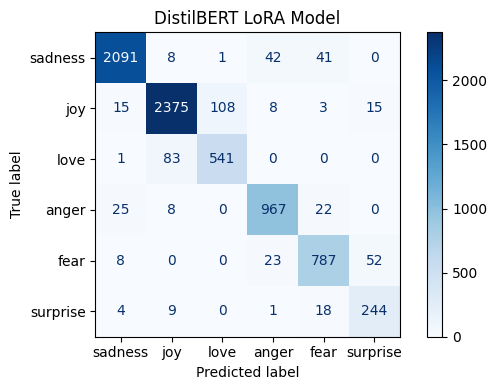

In [ ]:
print("\n=== ADAPTER CONFUSION MATRIX ===")
preds = trainer_adapter.predict(test_dataset)
y_true, y_pred = preds.label_ids, preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("DistilBERT LoRA Model")
plt.tight_layout()
plt.show()

### Adapter Training & Validation Loss

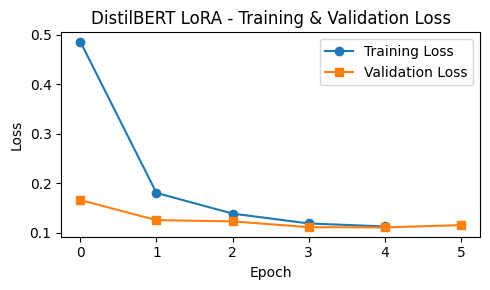

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_adapter.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_adapter.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('DistilBERT LoRA - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

### Comprehensive Comparison Table

In [ ]:
comparison_data = []

models = [
    ('Baseline DistilBERT', 'baseline_distilbert'),
    ('Fine-Tuned DistilBERT', 'finetuned_distilbert'),
    ('Adapter DistilBERT', 'adapter_distilbert')
]

for model_name, model_key in models:
    if model_key in results:
        metrics = results[model_key]
        row = {
            'Model': model_name,
            'Accuracy': metrics.get('eval_Accuracy', 0),
            'Precision': metrics.get('eval_Precision', 0),
            'Recall': metrics.get('eval_Recall', 0),
            'F1 Score': metrics.get('eval_F1 Score', 0),
            'Similarity': metrics.get('eval_Similarity Score', 0),
            'Confidence': metrics.get('eval_Confidence Score', 0),
            'Training Time (s)': metrics.get('training_time', 'N/A'),
            'Trainable Params': metrics.get('trainable_parameters', 'N/A'),
            'GPU Memory (GB)': metrics.get('gpu_memory_gb', 'N/A')
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

numeric_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Similarity', 'Confidence']
for col in numeric_columns:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)

print("\nCOMPREHENSIVE COMPARISON TABLE:")
print(comparison_df.to_string(index=False))


COMPREHENSIVE COMPARISON TABLE:
                Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s) Trainable Params GPU Memory (GB)
  Baseline DistilBERT    93.15     89.68  90.10    89.87      94.63      96.69               N/A              N/A             N/A
Fine-Tuned DistilBERT    93.59     89.18  92.70    90.72      95.61      95.51        645.616417         66958086        2.443905
   Adapter DistilBERT    93.40     89.69  91.65    90.61      95.75      94.56        547.000457           668934        2.083006


### Performance Visualization

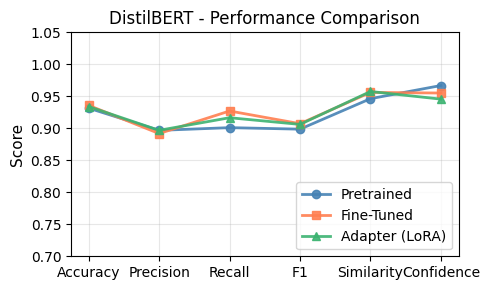

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "Similarity", "Confidence"]

# DistilBERT metrics
pretrained_vals = np.array([baseline_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
base_vals = np.array([finetuned_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
adapter_vals = np.array([adapter_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100

x = np.arange(len(metrics))

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(x, pretrained_vals, marker='o', linestyle='-', linewidth=2, alpha=0.9, label="Pretrained", color='steelblue')
ax.plot(x, base_vals, marker='s', linestyle='-', linewidth=2, alpha=0.9, label="Fine-Tuned", color='coral')
ax.plot(x, adapter_vals, marker='^', linestyle='-', linewidth=2, alpha=0.9, label="Adapter (LoRA)", color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.70, 1.05)
ax.set_title("DistilBERT - Performance Comparison", fontsize=12,)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

### Resource Usage Comparison

In [ ]:
# Extract data
distilbert_ft = results['finetuned_distilbert']
distilbert_ad = results['adapter_distilbert']

# DistilBERT Table
print("\n" + "DistilBERT - RESOURCE USAGE".center(40))
print("-" * 40)
print(f"{'Metric':<20} {'Fine-Tuned':<12} {'Adapter':<12}")
print("-" * 40)
print(f"{'Training Time (s)':<20} {distilbert_ft['training_time']:<12.0f} {distilbert_ad['training_time']:<12.0f}")
print(f"{'Trainable Params':<20} {distilbert_ft['trainable_parameters']:<12,} {distilbert_ad['trainable_parameters']:<12,}")
print(f"{'GPU Memory (GB)':<20} {distilbert_ft['gpu_memory_gb']:<12.2f} {distilbert_ad['gpu_memory_gb']:<12.2f}")
print("-" * 40)


      DistilBERT - RESOURCE USAGE       
----------------------------------------
Metric               Fine-Tuned   Adapter     
----------------------------------------
Training Time (s)    646          547         
Trainable Params     66,958,086   668,934     
GPU Memory (GB)      2.44         2.08        
----------------------------------------
